Project Title-Machine Failure Prediction

Problem Statement

This project aims to develop a machine learning classification model that predicts machine failures in advance using sensor readings such as temperature, torque, rotational speed, and tool wear.

In [2]:
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
path = r"c:\Users\Rahul Bamane\Downloads\classification-train-dataset.csv"
import pandas as pd
df = pd.read_csv(path)
df.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [4]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['Machine failure'].value_counts())

Shape: (136429, 14)

Data Types:
 id                           int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Missing Values:
 id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Target Distribution:
 Ma

Data Cleaning

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# Drop unnecessary columns
df = df.drop(['id', 'Product ID'], axis=1)

# Remove duplicates
df = df.drop_duplicates()

In [7]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')

 Exploratory Data Analysis (EDA)

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

Distribution of Numerical Features

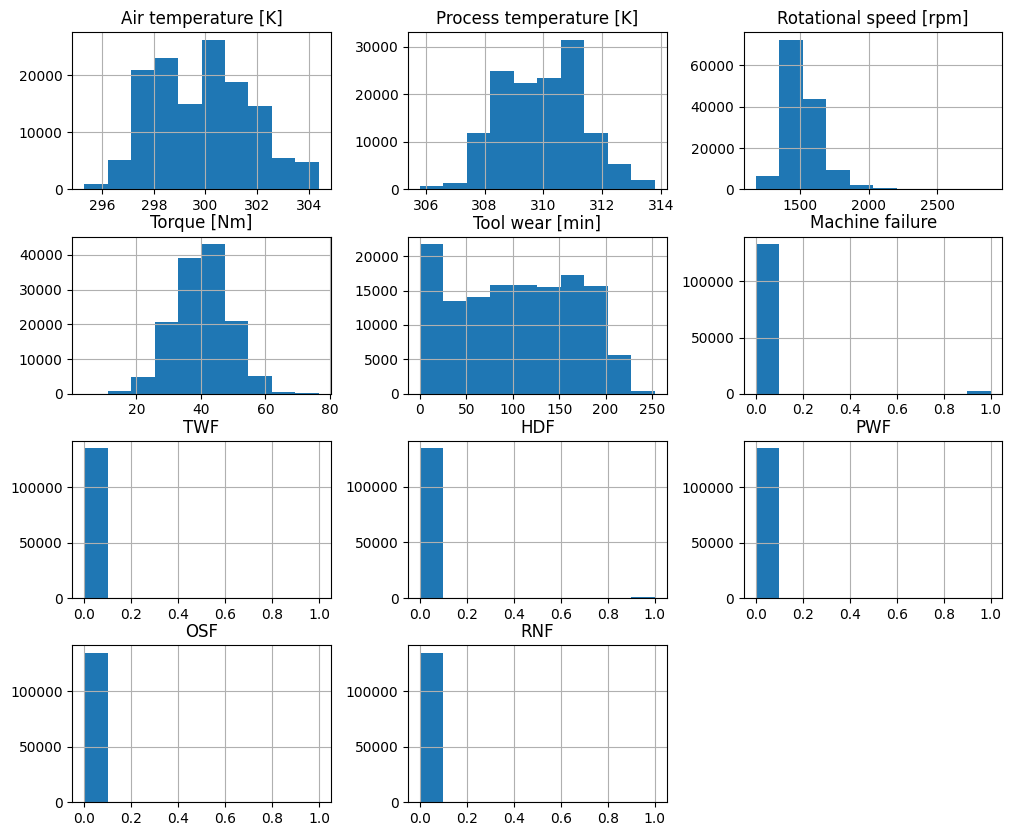

In [9]:
df.hist(figsize=(12,10))
plt.show()

Air temperature and Process temperature are normally distributed.

Torque and Tool wear show variation across machines.

Compare Failed vs Non-Failed

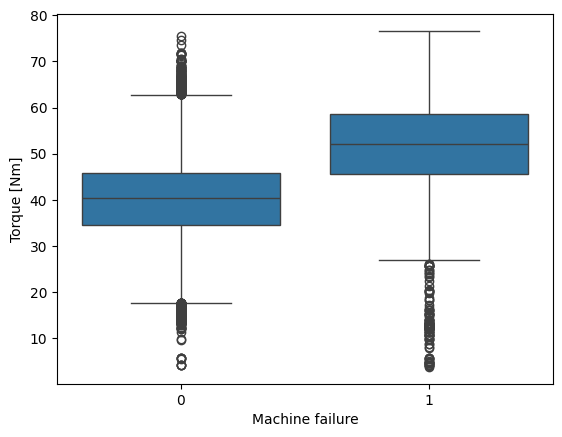

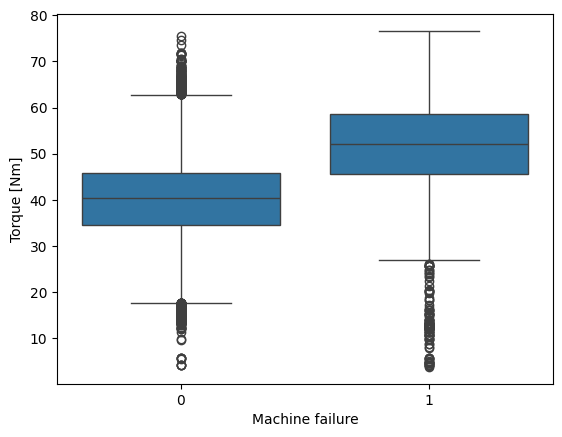

In [10]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()

Machines that failed generally have:

Higher Torque

Higher Tool Wear

Obervations:

Higher torque → more failures

Higher tool wear → higher probability of failure

Temperature difference matters

Data Cleaning and Data Preprocessing

In [11]:
df["Temp Difference"] = df["Process temperature [K]"] - df["Air temperature [K]"]

In [12]:
df.columns = (
    df.columns
      .str.replace(r'[\[\]<>]', '', regex=True)   # remove brackets
      .str.replace(' ', '_')                      # replace spaces
)

In [13]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])


In [14]:
X = df.drop('Machine_failure', axis=1)
Y= df['Machine_failure']

from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)
print(xtrain.shape,xtest.shape)

(108218, 12) (27055, 12)


In [15]:
cat = ['Type']
con= X.drop('Type', axis=1).columns

In [16]:
cat

['Type']

In [17]:
con

Index(['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm',
       'Torque_Nm', 'Tool_wear_min', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_Difference'],
      dtype='str')

In [18]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer



num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

pre = ColumnTransformer([
    ('cat',cat_pipe,cat),
    ('con',num_pipe,con)
]).set_output(transform='pandas')

X_pre = pre.fit_transform(X)
X_pre.head()

,cat__Type_0,cat__Type_1,cat__Type_2,con__Air_temperature_K,con__Process_temperature_K,con__Rotational_speed_rpm,con__Torque_Nm,con__Tool_wear_min,con__TWF,con__HDF,con__PWF,con__OSF,con__RNF,con__Temp_Difference
0,0.0,1.0,0.0,0.395546,-0.246363,0.545666,-0.499439,0.557371,-0.039243,-0.072174,-0.048695,-0.062895,-0.047615,-1.093499
1,0.0,0.0,1.0,1.469284,1.558786,1.721283,-1.323638,1.495664,-0.039243,-0.072174,-0.048695,-0.062895,-0.047615,-0.586292
2,0.0,1.0,0.0,-0.302383,-1.040629,2.053052,-1.629769,-1.241024,-0.039243,-0.072174,-0.048695,-0.062895,-0.047615,-0.890616
3,0.0,1.0,0.0,0.610294,0.692315,0.026375,0.466051,1.448750,-0.039243,-0.072174,-0.048695,-0.062895,-0.047615,-0.180526
4,0.0,0.0,1.0,-1.000313,-0.679599,0.870222,-0.581859,-1.100280,-0.039243,-0.072174,-0.048695,-0.062895,-0.047615,0.935331


In [19]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Since the dataset was highly imbalanced, the model was biased towards the majority class.
To improve detection of machine failures, we applied Random Under Sampling to balance the classes, which improved recall and ROC-AUC for the failure class.

In [20]:
from imblearn.over_sampling import SMOTE
SMT = SMOTE(random_state=42)
x_sampl,y_sampl = SMT.fit_resample(xtrain,ytrain)


In [21]:
y_sampl.value_counts()

Machine_failure
0    106515
1    106515
Name: count, dtype: int64

Model Building

In [22]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, classification_report

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


In [25]:
def evaluate_model(model, xtest, ytest):
    y_pred = model.predict(xtest)
    y_prob = model.predict_proba(xtest)[:,1]
    y_pred = (y_prob > 0.4).astype(int)

    print("Accuracy:", accuracy_score(ytest, y_pred))
    print("Precision:", precision_score(ytest, y_pred))
    print("Recall:", recall_score(ytest, y_pred))
    print("F1 Score:", f1_score(ytest, y_pred))
    print("ROC AUC:", roc_auc_score(ytest, y_prob))

    print("\nConfusion Matrix:")
    print(confusion_matrix(ytest, y_pred))

    print("\nClassification Report:")
    print(classification_report(ytest, y_pred))

 1. Logistic Regression

In [26]:
modelLR=LogisticRegression(class_weight='balanced')
modelLR.fit(xtrain,ytrain)
evaluate_model(modelLR,xtest,ytest)

Accuracy: 0.9624099057475513
Precision: 0.2735632183908046
Recall: 0.8380281690140845
F1 Score: 0.4124783362218371
ROC AUC: 0.942749283010139

Confusion Matrix:
[[25681   948]
 [   69   357]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     26629
           1       0.27      0.84      0.41       426

    accuracy                           0.96     27055
   macro avg       0.64      0.90      0.70     27055
weighted avg       0.99      0.96      0.97     27055



 2. Decision Tree


In [27]:
modelDTC=DecisionTreeClassifier(class_weight='balanced')
modelDTC.fit(xtrain,ytrain)
evaluate_model(modelDTC,xtest,ytest)

Accuracy: 0.991535760487895
Precision: 0.717439293598234
Recall: 0.7629107981220657
F1 Score: 0.7394766780432309
ROC AUC: 0.8790606873053258

Confusion Matrix:
[[26501   128]
 [  101   325]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26629
           1       0.72      0.76      0.74       426

    accuracy                           0.99     27055
   macro avg       0.86      0.88      0.87     27055
weighted avg       0.99      0.99      0.99     27055



 3. Random Forest Classifier


In [28]:
modelRFC=RandomForestClassifier(class_weight='balanced')
modelRFC.fit(xtrain,ytrain)
evaluate_model(modelRFC,xtest,ytest)

Accuracy: 0.9958602846054334
Precision: 0.961764705882353
Recall: 0.7676056338028169
F1 Score: 0.8537859007832899
ROC AUC: 0.9392706899199345

Confusion Matrix:
[[26616    13]
 [   99   327]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26629
           1       0.96      0.77      0.85       426

    accuracy                           1.00     27055
   macro avg       0.98      0.88      0.93     27055
weighted avg       1.00      1.00      1.00     27055



4.•	XG Boost Classifier

In [29]:
modelXGB = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

modelXGB.fit(xtrain,ytrain)
evaluate_model(modelXGB,xtest,ytest)


Accuracy: 0.9956754758824616
Precision: 0.9584569732937686
Recall: 0.7582159624413145
F1 Score: 0.8466579292267365
ROC AUC: 0.9501206545795232

Confusion Matrix:
[[26615    14]
 [  103   323]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26629
           1       0.96      0.76      0.85       426

    accuracy                           1.00     27055
   macro avg       0.98      0.88      0.92     27055
weighted avg       1.00      1.00      1.00     27055



5•	SVM

In [30]:
models = [modelLR,modelDTC,modelRFC,modelXGB]

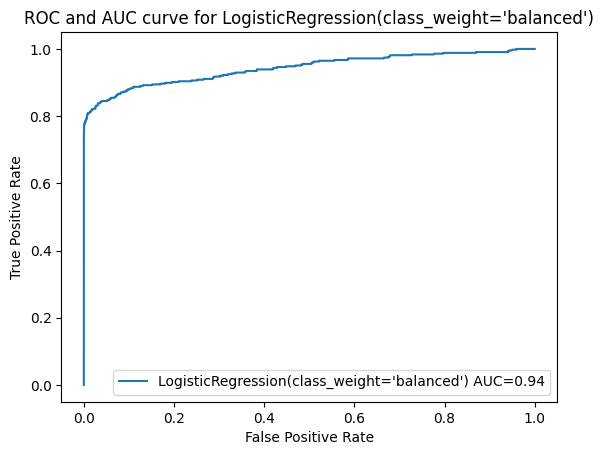

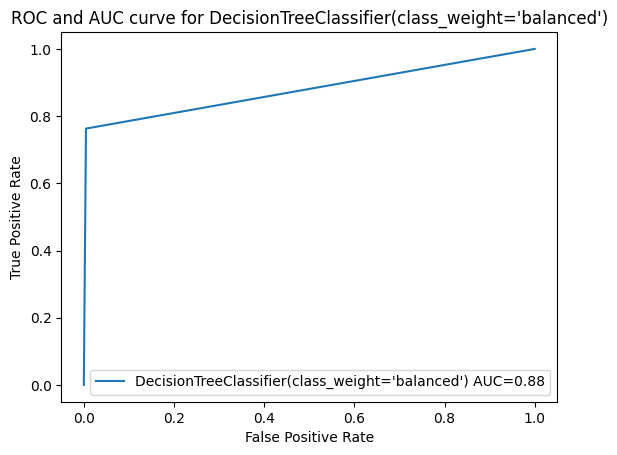

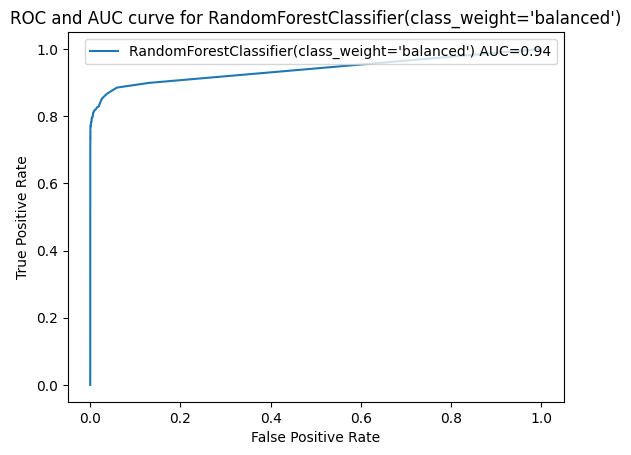

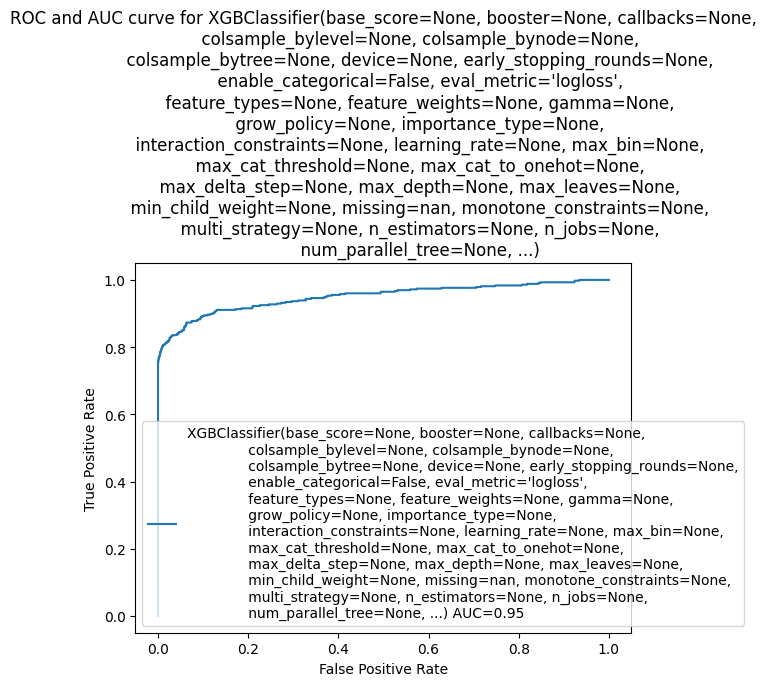

In [31]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
auc_scores =[]
    
for model in models:

    y_pred_proba =model.predict_proba(xtest)[:,1] 

    fpr,tpr,thresholds = roc_curve(ytest,y_pred_proba )

    roc_auc= auc(fpr,tpr) 

    auc_scores.append(roc_auc)

    plt.plot (fpr,tpr,label=f'{model} AUC={roc_auc:.2f}')

    plt.xlabel('False Positive Rate')

    plt.ylabel('True Positive Rate')

    plt.title(f'ROC and AUC curve for {model}')

    plt.legend()

    plt.show()   

Feature importance is only available for tree-based models, we will visualize it for:

1.Feature Importance – Decision Tree

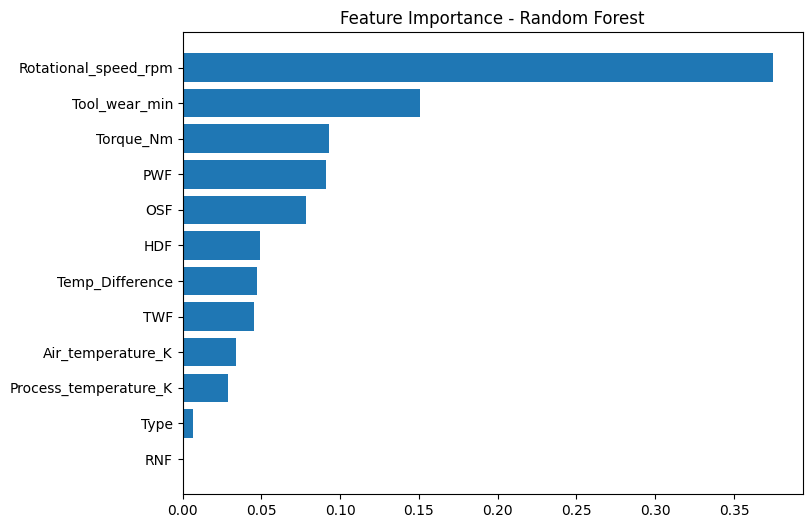

In [32]:
feature_names = xtrain.columns
importances = modelDTC.feature_importances_

if len(feature_names) == len(importances):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8,6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance - Random Forest")
    plt.show()
else:
    print("Mismatch in feature length and importance length!")

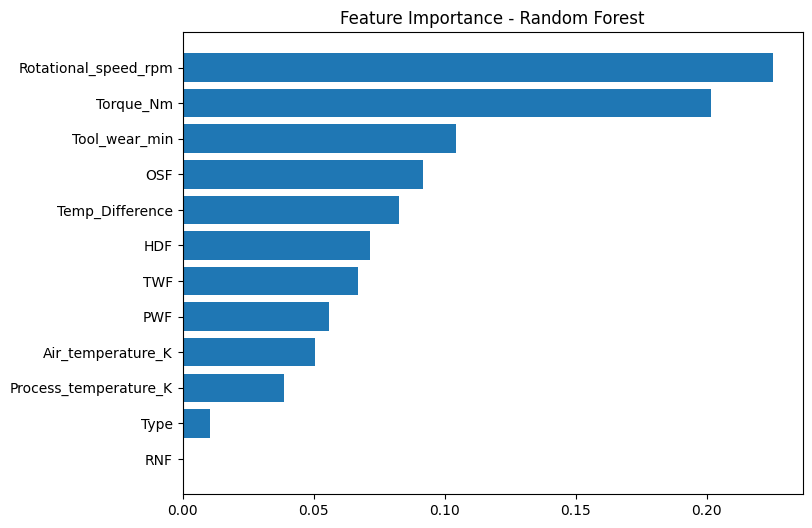

In [33]:
feature_names = xtrain.columns
importances = modelRFC.feature_importances_

if len(feature_names) == len(importances):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8,6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance - Random Forest")
    plt.show()
else:
    print("Mismatch in feature length and importance length!")

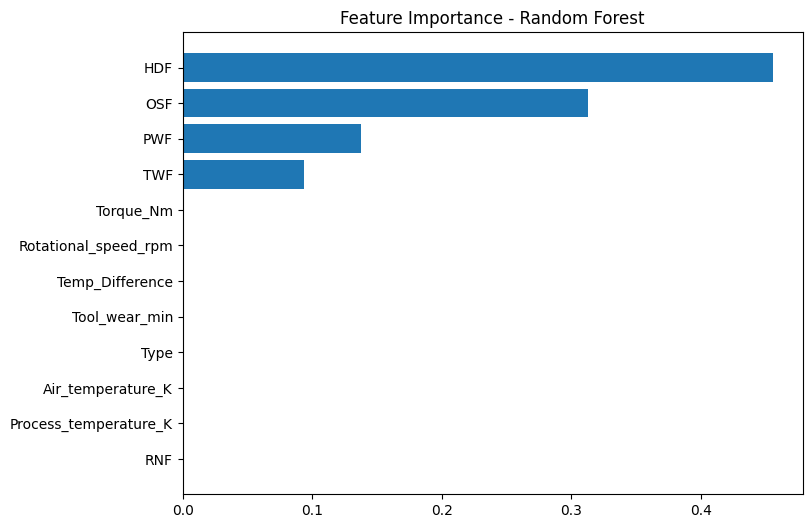

In [34]:
feature_names = xtrain.columns
importances = modelXGB.feature_importances_

if len(feature_names) == len(importances):
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8,6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance - Random Forest")
    plt.show()
else:
    print("Mismatch in feature length and importance length!")

In my project, ensemble-based models are:

Random Forest

XGBoost

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = xtrain.columns

rf_importances = modelRFC.feature_importances_

rf_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importances:\n")
print(rf_df)

Random Forest Feature Importances:

                  Feature  Importance
3    Rotational_speed_rpm    0.225420
4               Torque_Nm    0.201731
5           Tool_wear_min    0.104407
9                     OSF    0.091906
11        Temp_Difference    0.082418
7                     HDF    0.071564
6                     TWF    0.066953
8                     PWF    0.055790
1       Air_temperature_K    0.050543
2   Process_temperature_K    0.038594
0                    Type    0.010232
10                    RNF    0.000440


In [36]:
feature_names = xtrain.columns

rf_importances = modelXGB.feature_importances_

rf_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importances
}).sort_values(by="Importance", ascending=False)

print("Random Forest Feature Importances:\n")
print(rf_df)

Random Forest Feature Importances:

                  Feature  Importance
7                     HDF    0.455792
9                     OSF    0.312991
8                     PWF    0.137332
6                     TWF    0.093635
4               Torque_Nm    0.000041
3    Rotational_speed_rpm    0.000040
11        Temp_Difference    0.000037
5           Tool_wear_min    0.000037
0                    Type    0.000032
1       Air_temperature_K    0.000032
2   Process_temperature_K    0.000025
10                    RNF    0.000006


Model comparison Table

In [37]:
results=[]
for model in models:
    
    y_pred = model.predict(xtest)
    y_prob = model.predict_proba(xtest)[:,1]
    
    accuracy = accuracy_score(ytest, y_pred)
    precision = precision_score(ytest, y_pred)
    recall = recall_score(ytest, y_pred)
    f1 = f1_score(ytest, y_pred)
    roc_auc = roc_auc_score(ytest, y_prob)
    
    results.append([model, accuracy, precision, recall, f1, roc_auc])


In [38]:
comparison_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"
])

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LogisticRegression(class_weight='balanced'),0.986102,0.539062,0.809859,0.647280,0.942749
1,DecisionTreeClassifier(class_weight='balanced'),0.991536,0.717439,0.762911,0.739477,0.879061
2,"(DecisionTreeClassifier(max_features='sqrt', r...",0.995675,0.966767,0.751174,0.845443,0.939271
3,"XGBClassifier(base_score=None, booster=None, c...",0.995823,0.972810,0.755869,0.850727,0.950121


Combined Confusion Matrices (All Models Together)

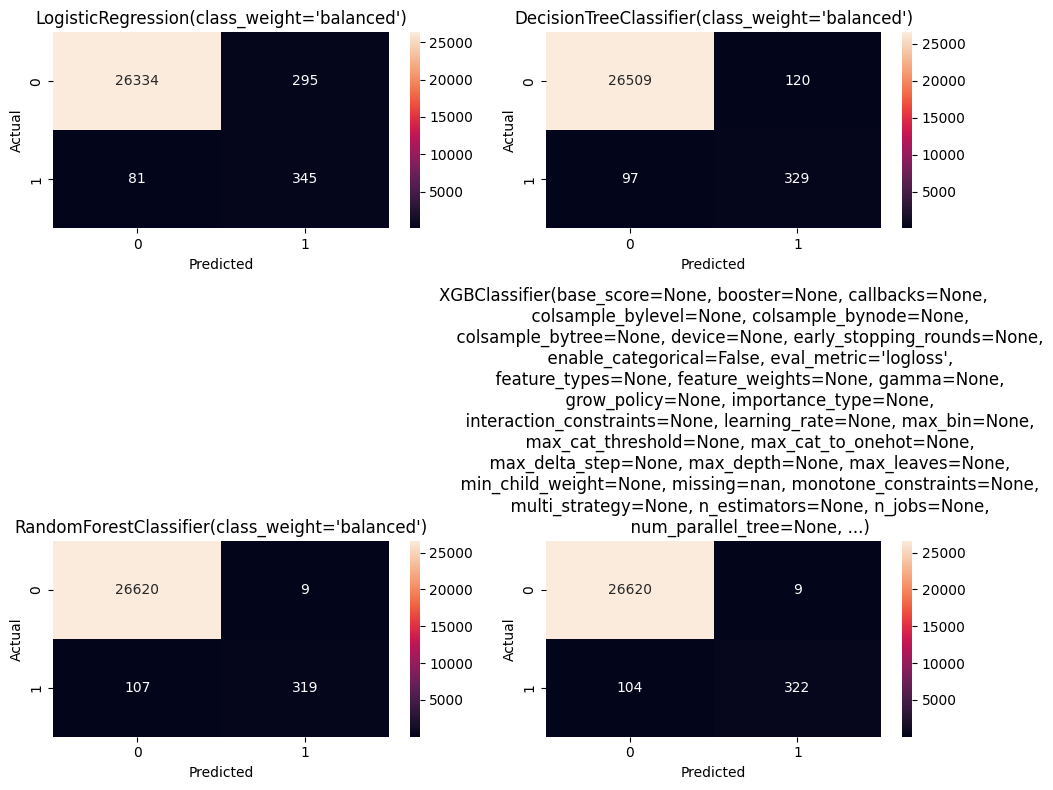

In [39]:
plt.figure(figsize=(10,8))

for i, model in enumerate(models):
    model.fit(xtrain,ytrain)
    y_pred = model.predict(xtest)
    
    # Confusion matrix
    cm = confusion_matrix(ytest, y_pred)
    
    # Plot subplot
    plt.subplot(2, 2, i+1)
    sns.heatmap(cm,annot=True, fmt='d')
    plt.title(model)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

•	Interpret results: e.g., if recall for failures is low, what does that imply?

If Recall is LOW:

The recall for machine failure indicates how effectively the model identifies actual failure cases. A low recall means the model fails to detect many real machine failures, leading to unexpected breakdowns and increased operational costs. Therefore, improving recall is critical for implementing effective predictive maintenance strategies

Insights & Conclusions

Based on feature importance from Random Forest and XGBoost.
1. Torque [Nm]

High torque increases mechanical stress.

Excessive load leads to component wear and overheating.

Strong indicator of overstrain failure.

🔹 2. Tool Wear [min]

Longer tool usage increases degradation.

Directly linked to tool wear failure (TWF).

One of the strongest predictors of breakdown.

🔹 3. Temperature Difference

(Process Temperature – Air Temperature)

Large temperature difference indicates overheating.

Heat dissipation problems (HDF) increase failure probability.

🔹 4. Rotational Speed [rpm]

Very high or very low speeds create imbalance.

Can contribute to mechanical instability.

Mechanical stress (torque), prolonged usage (tool wear), and overheating (temperature difference) are the primary contributors to machine failure.

2.Which Model Performed Best and Why?

Best Performing Model: XGBoost (or Random Forest)

Handles non-linear relationships
Robust to feature interactions
Works well with imbalanced data
Reduces overfitting using boosting
Achieves highest ROC-AUC score

3.How predictive maintenance can improve operational efficiency

Predictive maintenance helps companies save time, save money, and avoid sudden machine breakdowns.

In [40]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

In [41]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=modelXGB,
    param_grid=param_grid,
    scoring="roc_auc",  
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(xtrain,ytrain)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1], 'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parame

In [42]:
print("Best Parameters:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
Best ROC-AUC: 0.9655993580665723


In [43]:
best_xgb = grid.best_estimator_

y_pred = best_xgb.predict(xtest)
y_prob = best_xgb.predict_proba(xtest)[:,1]

In [44]:
import joblib
joblib.dump(pre,'pre.joblib')
joblib.dump(best_xgb, "best_xgb_model")

['best_xgb_model']

In [45]:
pre2 = joblib.load('pre.joblib')
m2 = joblib.load("best_xgb_model")

In [46]:
import pandas as pd
path2=r"c:\Users\Rahul Bamane\Downloads\classification-test-out of sample predictions.csv"
df2=pd.read_csv(path2)
df2

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90949,227378,L51130,L,302.3,311.4,1484,40.4,15,0,0,0,0,0
90950,227379,L47783,L,297.9,309.8,1542,33.8,31,0,0,0,0,0
90951,227380,L48097,L,295.6,306.2,1501,41.4,187,0,0,0,0,0
90952,227381,L48969,L,298.1,307.8,1534,40.3,69,0,0,0,0,0


In [50]:
df2.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='str')

In [58]:
df2["Temp_Difference"] = df2["Process temperature [K]"] - df2["Air temperature [K]"]

In [55]:
print(pre.feature_names_in_)

['Type' 'Air_temperature_K' 'Process_temperature_K' 'Rotational_speed_rpm'
 'Torque_Nm' 'Tool_wear_min' 'TWF' 'HDF' 'PWF' 'OSF' 'RNF'
 'Temp_Difference']


In [56]:
print(df2.columns)

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_Difference'],
      dtype='str')


In [64]:
df2 = df2[pre.feature_names_in_]


In [65]:
df2 = df2.reindex(columns=pre.feature_names_in_, fill_value=0)
pre_new = pre.transform(df2)

In [68]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("pre", pre),
    ("model", model)
])

pipe.fit(xtrain, ytrain)

# Now prediction is simple:
pipe.predict(df2)

array([0, 0, 0, ..., 0, 0, 0], shape=(90954,))

In [69]:
df2.to_csv("MFail_predictions.csv",index=False)

In [72]:
df2.head()

,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,TWF,HDF,PWF,OSF,RNF,Temp_Difference
0,L,0,0,0,0,0,0,0,0,0,0,9.2
1,L,0,0,0,0,0,0,0,0,0,0,9.3
2,L,0,0,0,0,0,0,0,0,0,0,9.1
3,M,0,0,0,0,0,0,0,0,0,0,9.5
4,M,0,0,0,0,0,0,0,0,0,0,8.9
